## Environment Setup

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Importing from Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Defining the path to folder in Google Drive
folder_path = '/content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset'

dataframes = {}

# Checking if the folder exists
if os.path.exists(folder_path):
    # List all files in the folder
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df_name = os.path.splitext(file_name)[0]  # Get filename without extension
            print(f'Loading {file_name}...')
            try:
                dataframes[df_name] = pd.read_csv(file_path)
                print(f'Successfully loaded {df_name}. Shape: {dataframes[df_name].shape}')
            except Exception as e:
                print(f'Error loading {file_name}: {e}')
else:
    print(f'Folder not found at: {folder_path}. Please check the path and ensure Google Drive is mounted correctly.')

# Display the first few rows of each loaded DataFrame for verification
for name, df in dataframes.items():
    print(f'\n--- {name}.head() ---')
    display(df.head())

Loading analysis_data_for_powerbi.csv...


/tmp/ipykernel_810/3891022966.py:15: DtypeWarning: Columns (17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[df_name] = pd.read_csv(file_path)


Successfully loaded analysis_data_for_powerbi. Shape: (3012669, 19)

--- analysis_data_for_powerbi.head() ---


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_status,order_delivered_timestamp,order_estimated_delivery_date
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
1,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
2,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,pending,NaN,NaN
3,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,pending,NaN,NaN
4,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,pending,NaN,NaN


### Loading Data from 'test' and 'train' Subfolders in Google Drive

In [ ]:
base_drive_path = '/content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/'

def load_data_from_subfolder(subfolder_name):
    full_subfolder_path = os.path.join(base_drive_path, subfolder_name)
    subfolder_dataframes = {}
    print(f'\n--- Loading data from {full_subfolder_path} ---')

    if os.path.exists(full_subfolder_path):
        for file_name in os.listdir(full_subfolder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(full_subfolder_path, file_name)
                df_name = file_name.replace('df_', '').replace('.csv', '') # e.g., 'Orders', 'Customers'
                print(f'Loading {file_name}...')
                try:
                    subfolder_dataframes[df_name.lower()] = pd.read_csv(file_path)
                    print(f'Successfully loaded {df_name} as \'{df_name.lower()}\' for {subfolder_name}. Shape: {subfolder_dataframes[df_name.lower()].shape}')
                except Exception as e:
                    print(f'Error loading {file_name} from {subfolder_name}: {e}')
    else:
        print(f'Subfolder not found: {full_subfolder_path}. Please check the path.')
    return subfolder_dataframes

# Load data from 'test' folder
test_data = load_data_from_subfolder('test')

# Load data from 'train' folder
train_data = load_data_from_subfolder('train')

print('\nSummary of loaded test dataframes:')
for name, df in test_data.items():
    print(f'{name}: {df.shape}')

print('\nSummary of loaded train dataframes:')
for name, df in train_data.items():
    print(f'{name}: {df.shape}')



--- Loading data from /content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/test ---
Loading df_Payments.csv...
Successfully loaded Payments as 'payments' for test. Shape: (38279, 5)
Loading df_Orders.csv...
Successfully loaded Orders as 'orders' for test. Shape: (38279, 4)
Loading df_Customers.csv...
Successfully loaded Customers as 'customers' for test. Shape: (38279, 4)
Loading df_Products.csv...
Successfully loaded Products as 'products' for test. Shape: (38279, 6)
Loading df_OrderItems.csv...
Successfully loaded OrderItems as 'orderitems' for test. Shape: (38279, 5)

--- Loading data from /content/drive/MyDrive/Data Projects/Kaggle: Ecommerce Order & Supply Chain Ecommerce Order & Supply Chain Dataset/Ecommerce Order Dataset/train ---
Loading df_Customers.csv...
Successfully loaded Customers as 'customers' for train. Shape: (89316, 4)
Loading df_OrderItems.csv...
Successfully loaded OrderItems as

### Merging and Combining 'test' and 'train' Datasets

In [ ]:
# Function to merge dataframes for a given dataset (test or train)
def create_analysis_df(data_dict, prefix):
    if all(key in data_dict for key in ['orders', 'customers', 'orderitems', 'products']):
        merged_df = (
            data_dict['orders']
            .merge(data_dict['customers'], on="customer_id", how="left")
            .merge(data_dict['orderitems'], on="order_id", how="left")
            .merge(data_dict['products'], on="product_id", how="left")
        )
        print(f'Successfully created {prefix}_analysis_df. Shape: {merged_df.shape}')
        return merged_df
    else:
        print(f'Could not create {prefix}_analysis_df. Missing one or more required dataframes (orders, customers, orderitems, products).')
        return pd.DataFrame()

# Create analysis_df for test data
test_analysis_df = create_analysis_df(test_data, 'test')

# Create analysis_df for train data
train_analysis_df = create_analysis_df(train_data, 'train')

# Combine test and train analysis dataframes
if not test_analysis_df.empty and not train_analysis_df.empty:
    combined_analysis_df = pd.concat([test_analysis_df, train_analysis_df], ignore_index=True)
    print(f'\nSuccessfully combined test and train data into combined_analysis_df. Shape: {combined_analysis_df.shape}')
    print('\nCombined Analysis DataFrame Head:')
    display(combined_analysis_df.head())
elif not test_analysis_df.empty:
    combined_analysis_df = test_analysis_df
    print(f'\nOnly test_analysis_df was created. Assigning it to combined_analysis_df. Shape: {combined_analysis_df.shape}')
elif not train_analysis_df.empty:
    combined_analysis_df = train_analysis_df
    print(f'\nOnly train_analysis_df was created. Assigning it to combined_analysis_df. Shape: {combined_analysis_df.shape}')
else:
    combined_analysis_df = pd.DataFrame()
    print('\nNo analysis dataframes could be created or combined.')


Successfully created test_analysis_df. Shape: (483183, 16)
Successfully created train_analysis_df. Shape: (2529486, 19)

Successfully combined test and train data into combined_analysis_df. Shape: (3012669, 19)

Combined Analysis DataFrame Head:


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_status,order_delivered_timestamp,order_estimated_delivery_date
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,NaN,NaN,NaN
1,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,NaN,NaN,NaN
2,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0,NaN,NaN,NaN
3,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,NaN,NaN,NaN
4,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0,NaN,NaN,NaN


## Data Cleaning & Preprocessing on Combined Dataset

Now that we have `combined_analysis_df`, we will apply cleaning and preprocessing steps based on the business requirements gathered.

### 3.1 Data Overview and Missing Values Check

In [ ]:
print("Combined DataFrame Info:")
display(combined_analysis_df.info())

print("\nMissing values in combined_analysis_df:")
display(combined_analysis_df.isnull().sum())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   order_id                       object 
 1   customer_id                    object 
 2   order_purchase_timestamp       object 
 3   order_approved_at              object 
 4   customer_zip_code_prefix       int64  
 5   customer_city                  object 
 6   customer_state                 object 
 7   product_id                     object 
 8   seller_id                      object 
 9   price                          float64
 10  shipping_charges               float64
 11  product_category_name          object 
 12  product_weight_g               float64
 13  product_length_cm              float64
 14  product_height_cm              float64
 15  product_width_cm               float64
 16  order_status                   object 
 17  order_delivered_times

None


Missing values in combined_analysis_df:


,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_approved_at,284
customer_zip_code_prefix,0
customer_city,0
customer_state,0
product_id,0
seller_id,0
price,0


### 3.2 Data Type Conversion and Missing Value Imputation

In [ ]:
# Convert timestamp columns to datetime objects
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]
for col in timestamp_cols:
    combined_analysis_df[col] = pd.to_datetime(combined_analysis_df[col], errors='coerce')

# Convert customer_zip_code_prefix to object/string as it's a categorical identifier
combined_analysis_df['customer_zip_code_prefix'] = combined_analysis_df['customer_zip_code_prefix'].astype(str)

# Handle missing values

# Fill missing product_category_name with 'Unknown'
combined_analysis_df['product_category_name'] = combined_analysis_df['product_category_name'].fillna('Unknown')

# Impute missing product dimensions with the median
product_dimension_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in product_dimension_cols:
    median_val = combined_analysis_df[col].median()
    combined_analysis_df[col] = combined_analysis_df[col].fillna(median_val)

# For 'order_approved_at', if missing, assume it was approved at the time of purchase
# This aligns with the 'improve order fulfillment efficiency' objective by ensuring a complete timeline.
combined_analysis_df['order_approved_at'] = combined_analysis_df['order_approved_at'].fillna(combined_analysis_df['order_purchase_timestamp'])

# For 'order_status', 'order_delivered_timestamp', and 'order_estimated_delivery_date':
# Missing values here are significant and indicate non-delivered or pending orders.
# We will fill 'order_status' with 'pending' if it's null.
combined_analysis_df['order_status'] = combined_analysis_df['order_status'].fillna('pending')

# For 'order_delivered_timestamp' and 'order_estimated_delivery_date',
# it's best to leave them as NaT (Not a Time) if the order was not delivered.
# This allows for accurate calculation of 'on-time delivery rate' and 'delivery delay duration'
# by clearly distinguishing delivered from non-delivered orders.


print("\nData types after conversion and missing value handling:")
display(combined_analysis_df.info())

print("\nMissing values after handling:")
display(combined_analysis_df.isnull().sum())


Data types after conversion and missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_purchase_timestamp       datetime64[ns]
 3   order_approved_at              datetime64[ns]
 4   customer_zip_code_prefix       object        
 5   customer_city                  object        
 6   customer_state                 object        
 7   product_id                     object        
 8   seller_id                      object        
 9   price                          float64       
 10  shipping_charges               float64       
 11  product_category_name          object        
 12  product_weight_g               float64       
 13  product_length_cm              float64       
 14  product_h

None


Missing values after handling:


,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_approved_at,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
product_id,0
seller_id,0
price,0


## Exploratory Data Analysis (EDA)

### Data Type Conversion

In [ ]:
# Convert timestamp columns to datetime objects for time-series analysis
combined_analysis_df['order_purchase_timestamp'] = pd.to_datetime(combined_analysis_df['order_purchase_timestamp'])
combined_analysis_df['order_approved_at'] = pd.to_datetime(combined_analysis_df['order_approved_at'])

print('Data types after conversion:')
display(combined_analysis_df.info())

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012669 entries, 0 to 3012668
Data columns (total 19 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_purchase_timestamp       datetime64[ns]
 3   order_approved_at              datetime64[ns]
 4   customer_zip_code_prefix       object        
 5   customer_city                  object        
 6   customer_state                 object        
 7   product_id                     object        
 8   seller_id                      object        
 9   price                          float64       
 10  shipping_charges               float64       
 11  product_category_name          object        
 12  product_weight_g               float64       
 13  product_length_cm              float64       
 14  product_height_cm              float6

None

### Distribution of Key Numerical Features

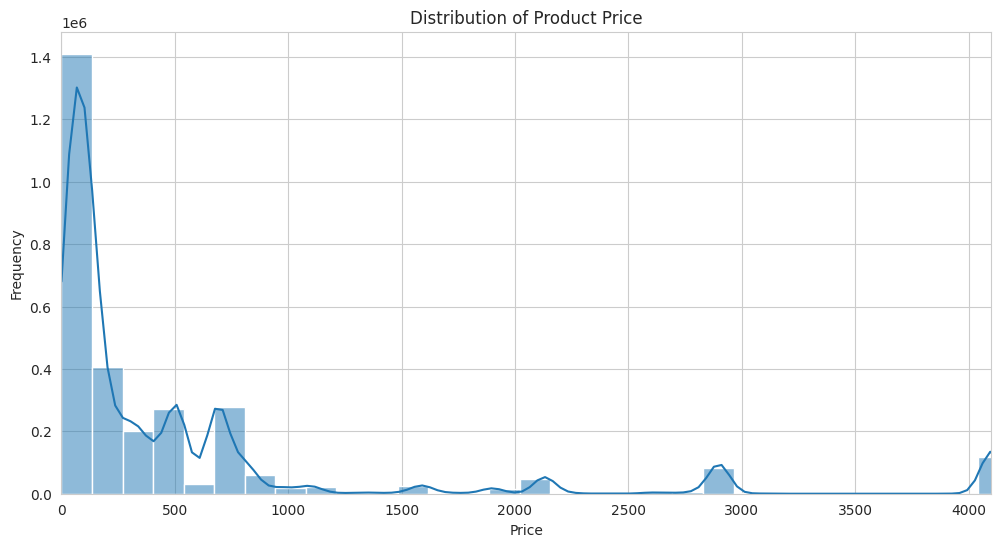

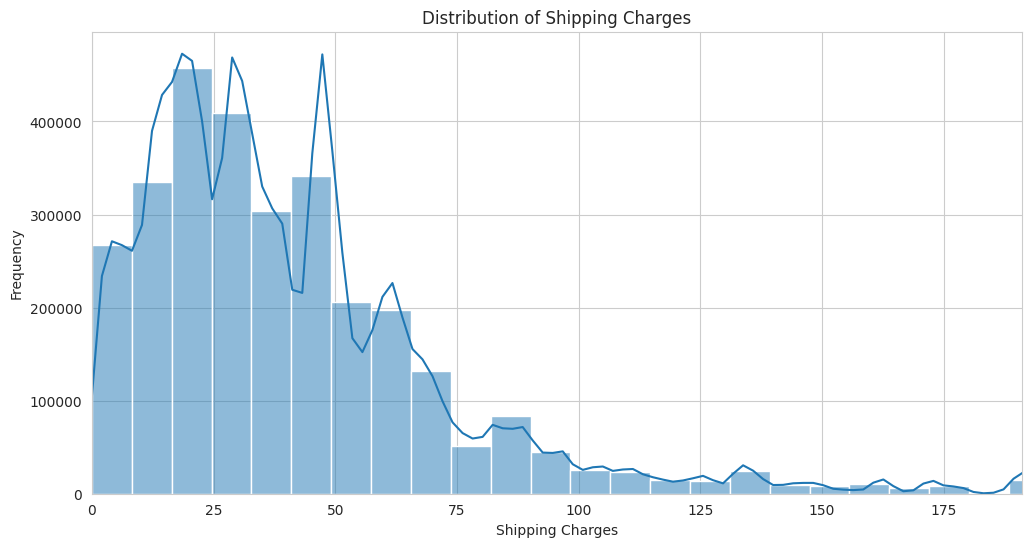

In [ ]:
# Set style for plots
sns.set_style('whitegrid')

# Distribution of Price
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['price'], bins=50, kde=True)
plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['price'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.show()

# Distribution of Shipping Charges
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['shipping_charges'], bins=50, kde=True)
plt.title('Distribution of Shipping Charges')
plt.xlabel('Shipping Charges')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['shipping_charges'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.show()

### Distribution of Product Categories

/tmp/ipykernel_810/881530459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


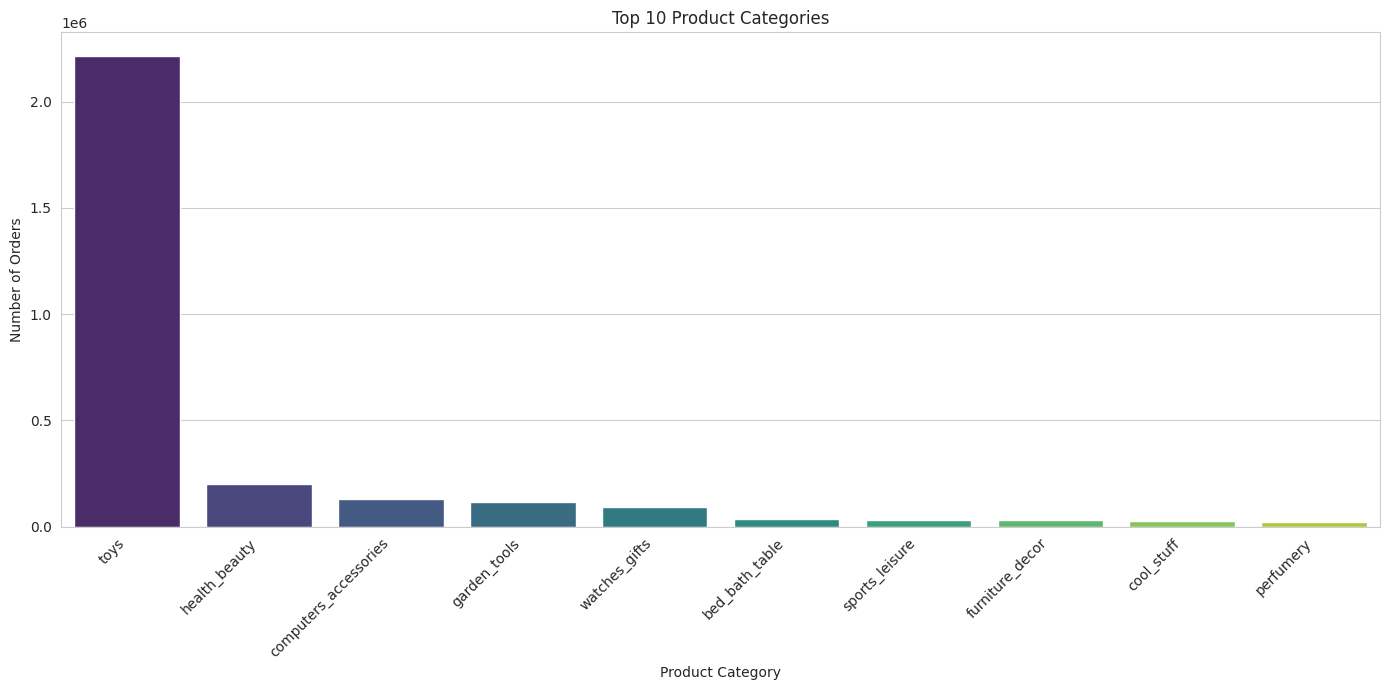

In [ ]:
# Fill missing product category names with 'Unknown' for better visualization
combined_analysis_df['product_category_name'] = combined_analysis_df['product_category_name'].fillna('Unknown')

# Top 10 Product Categories
plt.figure(figsize=(14, 7))
top_categories = combined_analysis_df['product_category_name'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Sales Trends Over Time

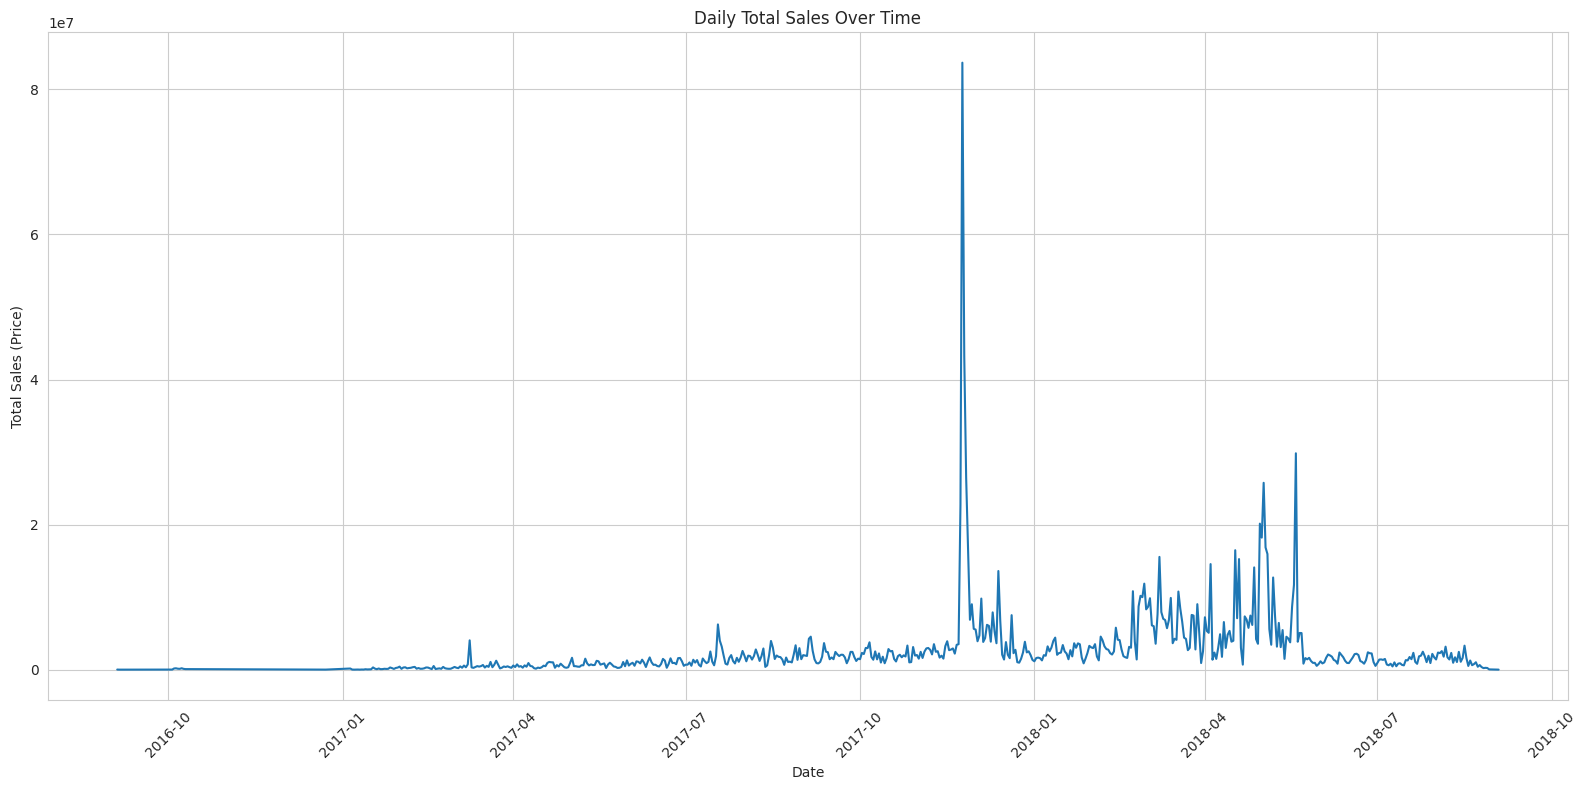

In [ ]:
# Aggregate total sales by order purchase timestamp (daily)
daily_sales = combined_analysis_df.groupby(combined_analysis_df['order_purchase_timestamp'].dt.date)['price'].sum().reset_index()
daily_sales['order_purchase_timestamp'] = pd.to_datetime(daily_sales['order_purchase_timestamp'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_timestamp', y='price', data=daily_sales)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (Price)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Order Volume

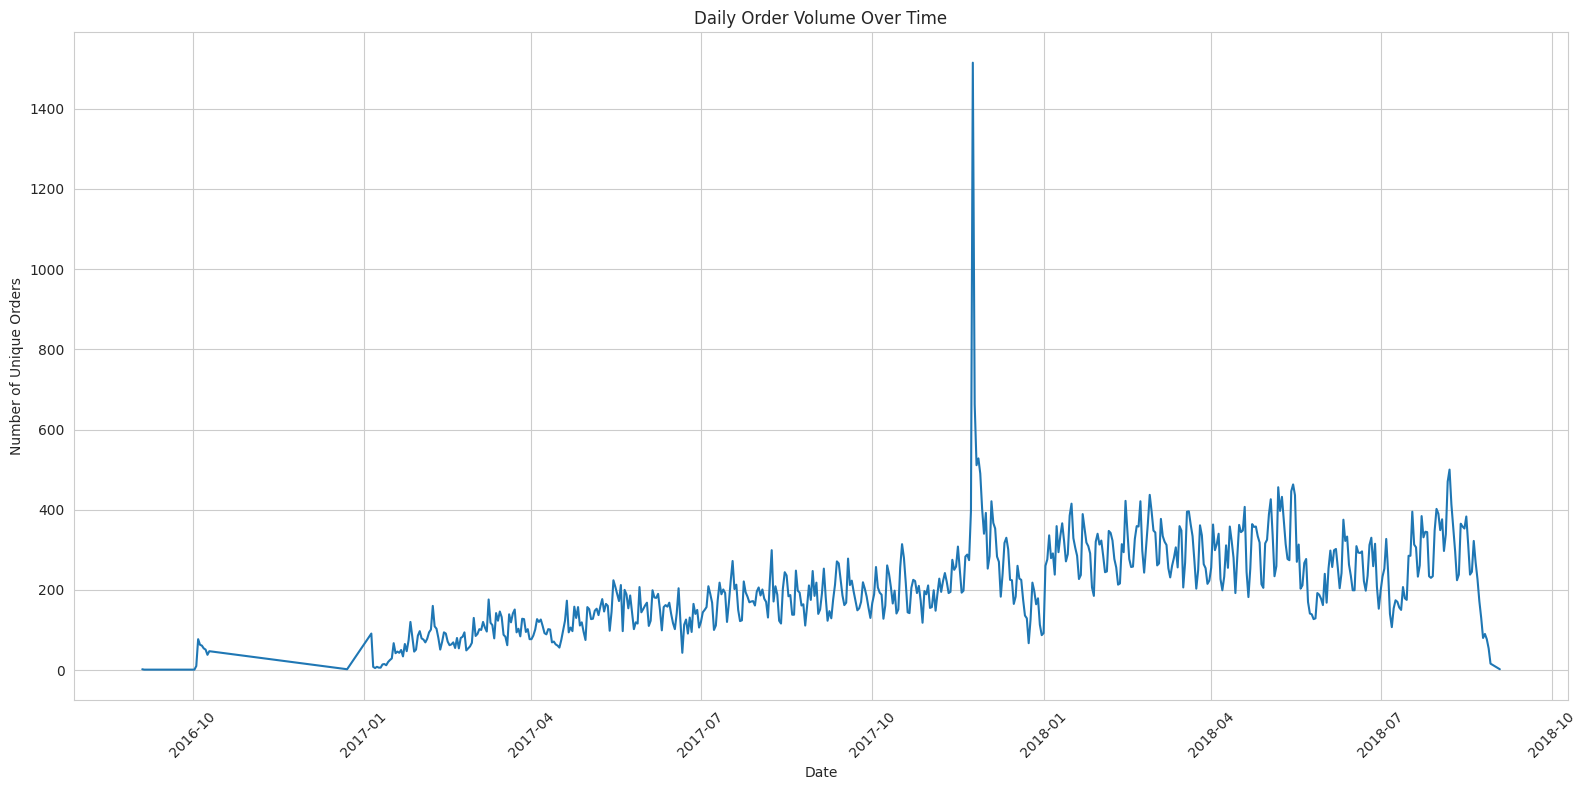

In [ ]:
# Aggregate daily order volume
daily_order_volume = combined_analysis_df.groupby(combined_analysis_df['order_purchase_timestamp'].dt.date)['order_id'].nunique().reset_index()
daily_order_volume['order_purchase_timestamp'] = pd.to_datetime(daily_order_volume['order_purchase_timestamp'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_timestamp', y='order_id', data=daily_order_volume)
plt.title('Daily Order Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Unique Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Real-time Delivery Status Analysis

To understand the delivery performance, calculation on several time-related metrics and visualize the distribution of order statuses and delivery outcomes was done to produce the results needed

In [ ]:
# Calculate Delivery Lead Time (Time from purchase to actual delivery)
# Only for delivered orders, otherwise it will be NaT
combined_analysis_df['delivery_lead_time'] = (combined_analysis_df['order_delivered_timestamp'] - combined_analysis_df['order_purchase_timestamp']).dt.days

# Calculate Delivery Delay (Actual delivery vs. Estimated delivery)
# Positive values mean delayed, negative values mean delivered early
combined_analysis_df['delivery_delay'] = (combined_analysis_df['order_delivered_timestamp'] - combined_analysis_df['order_estimated_delivery_date']).dt.days

# Create a categorical variable for on-time delivery
combined_analysis_df['on_time_delivery'] = combined_analysis_df['delivery_delay'].apply(lambda x: 'Delayed'
    if x > 0
    else ('On-time/Early' if x <= 0 and pd.notna(x) else 'Not Delivered/Pending'))

print("New delivery-related features created:")
display(combined_analysis_df[['order_purchase_timestamp', 'order_delivered_timestamp', 'order_estimated_delivery_date', 'delivery_lead_time', 'delivery_delay', 'on_time_delivery']].head(-10))

New delivery-related features created:


,order_purchase_timestamp,order_delivered_timestamp,order_estimated_delivery_date,delivery_lead_time,delivery_delay,on_time_delivery
0,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
1,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
2,2017-11-18 12:29:57,NaT,NaT,NaN,NaN,Not Delivered/Pending
3,2018-06-02 17:13:12,NaT,NaT,NaN,NaN,Not Delivered/Pending
4,2018-06-02 17:13:12,NaT,NaT,NaN,NaN,Not Delivered/Pending
...,...,...,...,...,...,...
3012654,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012655,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012656,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early
3012657,2018-08-11 08:04:22,2018-08-14 21:43:51,2018-08-17,3.0,-3.0,On-time/Early


#### Distribution of Order Statuses

/tmp/ipykernel_810/600305979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='order_status', data=combined_analysis_df, order=combined_analysis_df['order_status'].value_counts().index, palette='viridis')


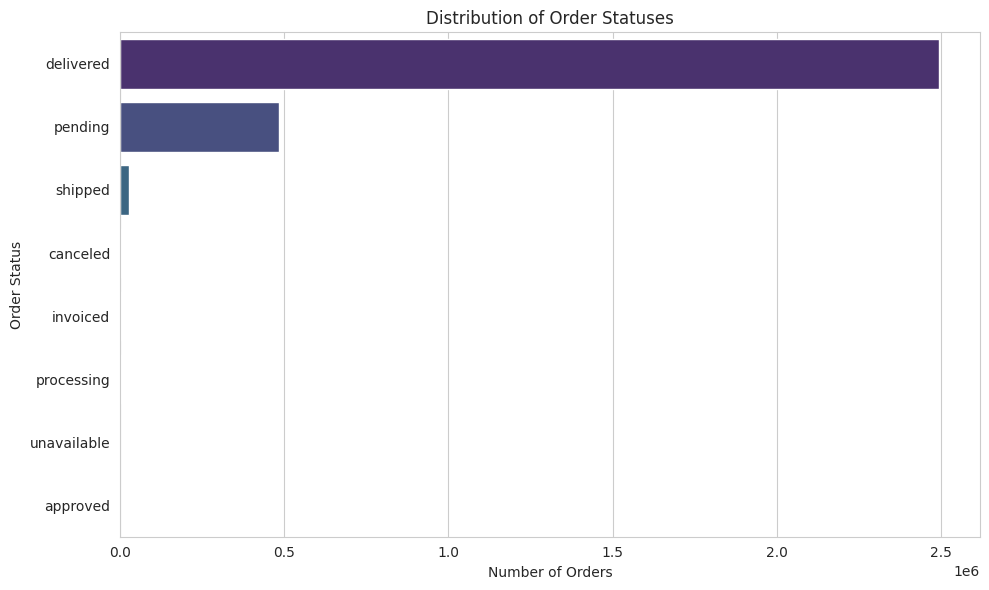

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='order_status', data=combined_analysis_df, order=combined_analysis_df['order_status'].value_counts().index, palette='viridis')
plt.title('Distribution of Order Statuses')
plt.xlabel('Number of Orders')
plt.ylabel('Order Status')
plt.tight_layout()
plt.show()

#### Distribution of Delivery Lead Time

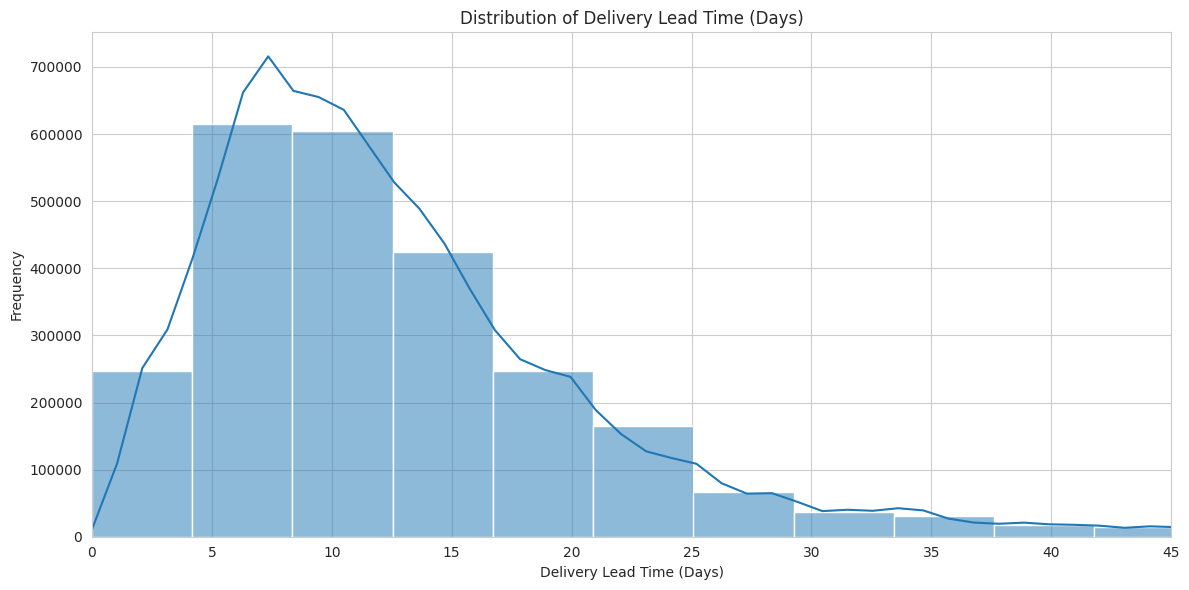

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(combined_analysis_df['delivery_lead_time'].dropna(), bins=50, kde=True)
plt.title('Distribution of Delivery Lead Time (Days)')
plt.xlabel('Delivery Lead Time (Days)')
plt.ylabel('Frequency')
plt.xlim(0, combined_analysis_df['delivery_lead_time'].quantile(0.99)) # Limit x-axis to 99th percentile
plt.tight_layout()
plt.show()

#### On-time Delivery Rate

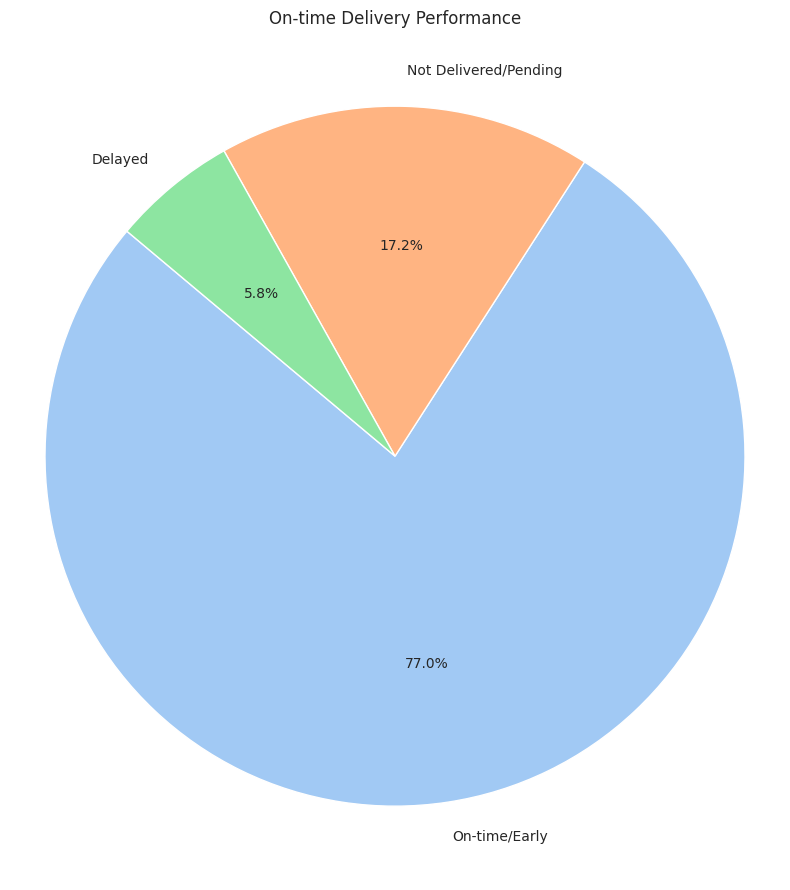

In [ ]:
on_time_delivery_counts = combined_analysis_df['on_time_delivery'].value_counts(normalize=True).mul(100).reset_index()
on_time_delivery_counts.columns = ['Delivery Status', 'Percentage']

plt.figure(figsize=(8, 9))
plt.pie(on_time_delivery_counts['Percentage'], labels=on_time_delivery_counts['Delivery Status'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('On-time Delivery Performance')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## Key Business Measures Calculation

### Total Revenue

In [ ]:
# Calculate Total Revenue (price + shipping charges) per order item
combined_analysis_df['total_revenue'] = combined_analysis_df['price'] + combined_analysis_df['shipping_charges']

print("Total Revenue column added to combined_analysis_df:")
display(combined_analysis_df[['order_id', 'price', 'shipping_charges', 'total_revenue']].head())

Total Revenue column added to combined_analysis_df:


,order_id,price,shipping_charges,total_revenue
0,u6rPMRAYIGig,24.10,20.90,45.00
1,u6rPMRAYIGig,24.10,20.90,45.00
2,u6rPMRAYIGig,24.10,20.90,45.00
3,ohY8f4FEbX19,42.89,12.28,55.17
4,ohY8f4FEbX19,42.89,12.28,55.17


### Average Order Value (AOV)

In [ ]:
# Calculate Average Order Value (Total Revenue ÷ Number of Orders)
# First, calculate total revenue per unique order
revenue_per_order = combined_analysis_df.groupby('order_id')['total_revenue'].sum().reset_index()

aov = revenue_per_order['total_revenue'].mean()

print(f"Average Order Value (AOV): ${aov:,.2f}")

Average Order Value (AOV): $13,845.84


### On-time Delivery Rate

In [ ]:
# On-time delivery rate has already been calculated in the 'on_time_delivery_counts' DataFrame
# We can extract the 'On-time/Early' percentage.

on_time_percentage = on_time_delivery_counts[on_time_delivery_counts['Delivery Status'] == 'On-time/Early']['Percentage'].iloc[0]

print(f"On-time Delivery Rate: {on_time_percentage:.2f}%")

On-time Delivery Rate: 77.00%


### Customer Lifetime Value (CLV)

In [ ]:
# Calculate Customer Lifetime Value (CLV = Total Revenue per Customer)
clv_per_customer = combined_analysis_df.groupby('customer_id')['total_revenue'].sum().reset_index()
clv_per_customer.rename(columns={'total_revenue': 'customer_lifetime_value'}, inplace=True)

print("Top 10 Customers by CLV:")
display(clv_per_customer.sort_values(by='customer_lifetime_value', ascending=False).head(10))

Top 10 Customers by CLV:


,customer_id,customer_lifetime_value
91389,iXo3TsSEqJUj,1618190.32
12385,64cF8eKRwCzv,1618190.32
56478,RdIqpewtj5wL,1614034.77
116917,urQhymkpjw5b,1614034.77
8509,4APqQ2Wdl7cU,1614034.77
90851,iH6EXp6pYkxV,1614034.77
82330,eDX2NAk8RJvG,1603854.63
9266,4X4KBG3YnsgQ,1599695.25
47701,NMfQkUiFYfIg,1599695.25
125566,z2rmeYNL4iA1,1599695.25


### Payment Success Rate

In [ ]:
# Combine test and train payments dataframes
all_payments_df = pd.concat([test_data['payments'], train_data['payments']], ignore_index=True)

# Count unique orders with recorded payments (assuming these are successful)
successful_payments_count = all_payments_df['order_id'].nunique()

# Count total unique orders from the combined analysis dataframe
total_orders_count = combined_analysis_df['order_id'].nunique()

# Calculate Payment Success Rate
payment_success_rate = (successful_payments_count / total_orders_count) * 100

print(f"Number of Unique Orders with Recorded Payments: {successful_payments_count}")
print(f"Total Unique Orders: {total_orders_count}")
print(f"Payment Success Rate: {payment_success_rate:.2f}%")

Number of Unique Orders with Recorded Payments: 127595
Total Unique Orders: 127595
Payment Success Rate: 100.00%


### Category-level Sales

In [ ]:
# Calculate total sales per product category
category_sales = combined_analysis_df.groupby('product_category_name')['total_revenue'].sum().reset_index()
category_sales.rename(columns={'total_revenue': 'total_category_sales'}, inplace=True)

print("Top 10 Product Categories by Sales:")
display(category_sales.sort_values(by='total_category_sales', ascending=False).head(10).style.format({'total_category_sales': '{:,.2f}'}))

Top 10 Product Categories by Sales:


,product_category_name,total_category_sales
69,toys,"1,392,003,360.21"
42,garden_tools,"191,663,608.00"
43,health_beauty,"38,306,026.56"
15,computers_accessories,"29,979,649.76"
70,watches_gifts,"28,652,781.04"
68,telephony,"16,346,786.27"
39,furniture_decor,"11,948,941.31"
8,bed_bath_table,"10,146,775.07"
65,sports_leisure,"8,299,562.28"
20,cool_stuff,"6,076,553.71"


### Regional Sales Performance (by Customer State)

To monitor sales performance across regions, we'll analyze total revenue by customer state. It is important to note that each state has it's weighted currency and that should be considered per region.

Top 10 Customer States by Sales:


,customer_state,total_state_sales
25,SP,"654,292,703.90"
18,RJ,"251,017,913.34"
10,MG,"244,124,125.87"
22,RS,"97,195,789.28"
17,PR,"87,695,195.73"
8,GO,"67,081,377.09"
4,BA,"66,195,240.96"
23,SC,"58,731,246.95"
7,ES,"39,753,166.37"
5,CE,"34,787,378.92"


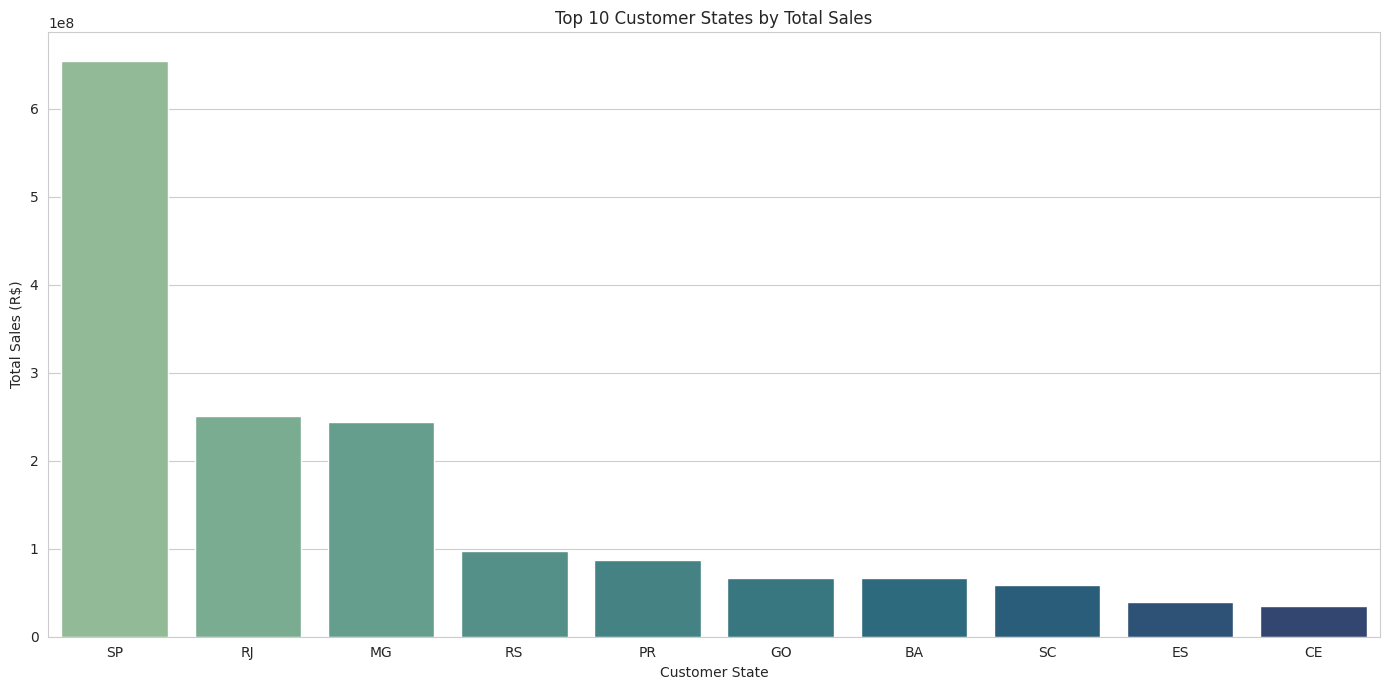

In [ ]:
# Calculate total sales per customer state
state_sales = combined_analysis_df.groupby('customer_state')['total_revenue'].sum().reset_index()
state_sales.rename(columns={'total_revenue': 'total_state_sales'}, inplace=True)

# Sort and display top 10 states by sales
print("Top 10 Customer States by Sales:")
display(state_sales.sort_values(by='total_state_sales', ascending=False).head(10).style.format({'total_state_sales': '{:,.2f}'}))

# Visualize top 10 states by sales
plt.figure(figsize=(14, 7))
sns.barplot(x='customer_state', y='total_state_sales', data=state_sales.sort_values(by='total_state_sales', ascending=False).head(10), palette='crest', hue='customer_state', legend=False)
plt.title('Top 10 Customer States by Total Sales')
plt.xlabel('Customer State')
plt.ylabel('Total Sales (R$)')
plt.tight_layout()
plt.show()

### Seller Performance Analysis

To evaluate seller performance, we'll look at the total revenue generated by each seller and the number of unique orders they processed.

In [ ]:
# Calculate total revenue per seller
seller_revenue = combined_analysis_df.groupby('seller_id')['total_revenue'].sum().reset_index()
seller_revenue.rename(columns={'total_revenue': 'seller_total_revenue'}, inplace=True)

# Calculate number of unique orders per seller
seller_orders = combined_analysis_df.groupby('seller_id')['order_id'].nunique().reset_index()
seller_orders.rename(columns={'order_id': 'seller_order_count'}, inplace=True)

# Merge these two dataframes
seller_performance = pd.merge(seller_revenue, seller_orders, on='seller_id', how='left')

# Sort and display top 10 sellers by revenue
print("Top 10 Sellers by Total Revenue:")
display(seller_performance.sort_values(by='seller_total_revenue', ascending=False).head(10).style.format({'seller_total_revenue': '{:,.2f}'}))

# Sort and display top 10 sellers by order count, applying formatting to revenue column
print("\nTop 10 Sellers by Order Count:")
display(seller_performance.sort_values(by='seller_order_count', ascending=False).head(10).style.format({'seller_total_revenue': '{:,.2f}'}))

Top 10 Sellers by Total Revenue:


,seller_id,seller_total_revenue,seller_order_count
2674,r7VxefoTVHbb,"946,634,758.76",2157
3019,yGbPyLPc8PmT,"97,243,006.68",2333
1365,RKad98cTxhSb,"53,230,168.21",2352
1014,K0qPVGdA91KO,"46,853,996.86",1615
1504,TuPm19CMKvrM,"37,872,329.95",2055
1521,UOGIrJtSldvd,"31,659,133.39",1580
2856,v4i9GZGfxgTZ,"27,389,163.96",376
19,0Mzbc3aACMOQ,"26,284,444.88",849
1957,coi9xkdo66JI,"24,732,316.98",1242
2715,ruq0u2ZpAMDr,"18,425,044.00",1848



Top 10 Sellers by Order Count:


,seller_id,seller_total_revenue,seller_order_count
1365,RKad98cTxhSb,"53,230,168.21",2352
3019,yGbPyLPc8PmT,"97,243,006.68",2333
2674,r7VxefoTVHbb,"946,634,758.76",2157
1504,TuPm19CMKvrM,"37,872,329.95",2055
2715,ruq0u2ZpAMDr,"18,425,044.00",1848
1014,K0qPVGdA91KO,"46,853,996.86",1615
1521,UOGIrJtSldvd,"31,659,133.39",1580
714,EGW4UK5bOeEZ,"7,939,277.09",1531
2370,l1pYW6GBnPMr,"9,986,364.73",1316
1731,YVBAT3QqF9Qj,"8,108,227.91",1290


### Seasonality Analysis: Monthly Sales Trends

To further understand seasonality, we'll extract the month from the purchase timestamp and visualize total sales per month.

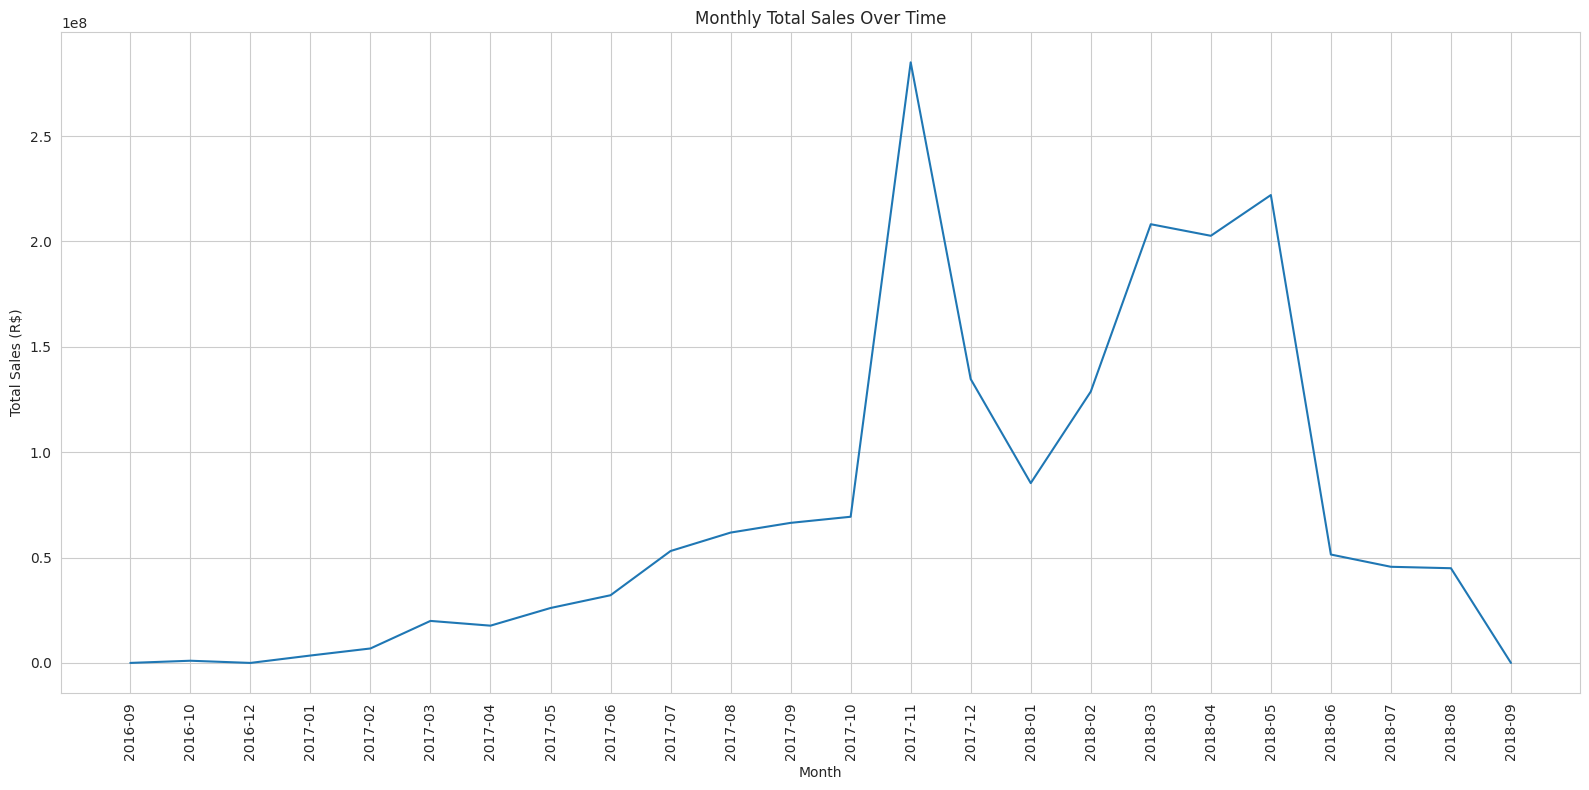

In [ ]:
# Extract month and year from order purchase timestamp
combined_analysis_df['order_purchase_month'] = combined_analysis_df['order_purchase_timestamp'].dt.to_period('M')

# Aggregate total sales by month
monthly_sales = combined_analysis_df.groupby('order_purchase_month')['total_revenue'].sum().reset_index()
monthly_sales['order_purchase_month'] = monthly_sales['order_purchase_month'].astype(str)

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_month', y='total_revenue', data=monthly_sales)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales (R$)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Monthly Revenue Growth Rate

To understand the growth trajectory, we will calculate the monthly revenue growth rate.

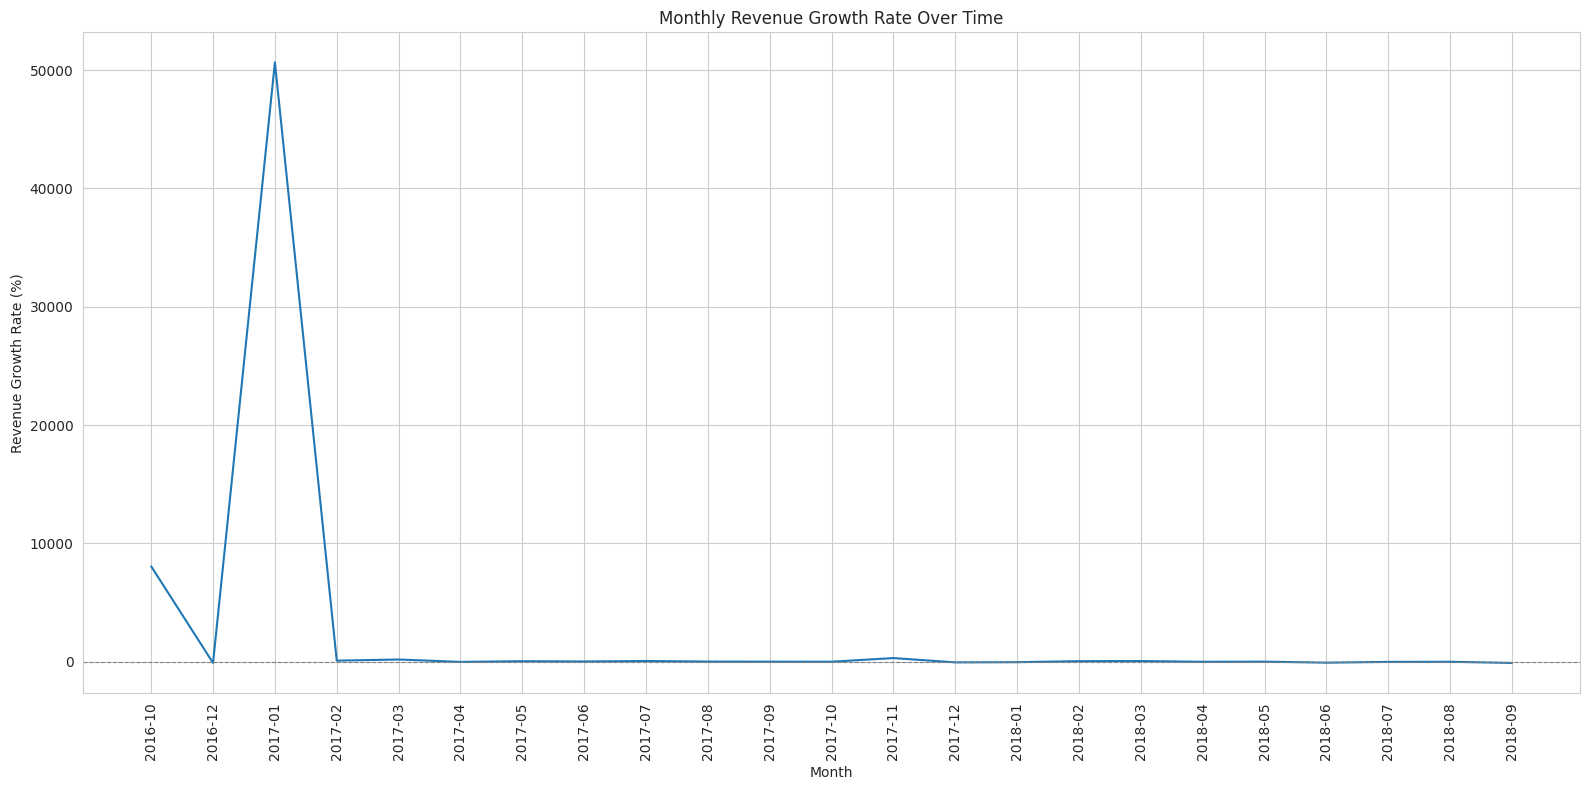

In [ ]:
monthly_sales['revenue_growth_rate'] = monthly_sales['total_revenue'].pct_change() * 100

plt.figure(figsize=(16, 8))
sns.lineplot(x='order_purchase_month', y='revenue_growth_rate', data=monthly_sales.dropna())
plt.title('Monthly Revenue Growth Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue Growth Rate (%)')
plt.xticks(rotation=90)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.tight_layout()
plt.show()


## Understanding customer purchasing behavior

In [ ]:
print(f"Average Order Value (AOV): ${aov:,.2f}")

print("\nTop 10 Customers by CLV:")
display(clv_per_customer.sort_values(by='customer_lifetime_value', ascending=False).head(10))

print("\nTop 10 Product Categories by Sales:")
display(category_sales.sort_values(by='total_category_sales', ascending=False).head(10))

Average Order Value (AOV): $13,845.84

Top 10 Customers by CLV:


,customer_id,customer_lifetime_value
91389,iXo3TsSEqJUj,1618190.32
12385,64cF8eKRwCzv,1618190.32
56478,RdIqpewtj5wL,1614034.77
116917,urQhymkpjw5b,1614034.77
8509,4APqQ2Wdl7cU,1614034.77
90851,iH6EXp6pYkxV,1614034.77
82330,eDX2NAk8RJvG,1603854.63
9266,4X4KBG3YnsgQ,1599695.25
47701,NMfQkUiFYfIg,1599695.25
125566,z2rmeYNL4iA1,1599695.25



Top 10 Product Categories by Sales:


,product_category_name,total_category_sales
69,toys,1.392003e+09
42,garden_tools,1.916636e+08
43,health_beauty,3.830603e+07
15,computers_accessories,2.997965e+07
70,watches_gifts,2.865278e+07
68,telephony,1.634679e+07
39,furniture_decor,1.194894e+07
8,bed_bath_table,1.014678e+07
65,sports_leisure,8.299562e+06
20,cool_stuff,6.076554e+06


##   Exporting Data for generating reports

In [ ]:
# Define the output file path
output_csv_path = 'exploratory_analysis.csv'

# Export the analysis_df to a CSV file
combined_analysis_df.to_csv(output_csv_path, index=False)

print(f"Data successfully exported to '{output_csv_path}'")
print("You can now download this file from the file browser in the left panel of Colab or by running the following code:")
print("from google.colab import files")
print(f"files.download('{output_csv_path}')")

from google.colab import files
files.download('analysis_data_for_powerbi.csv')

Data successfully exported to 'exploratory_analysis.csv'
You can now download this file from the file browser in the left panel of Colab or by running the following code:
from google.colab import files
files.download('exploratory_analysis.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>